In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import scipy
from scipy.signal import resample_poly
import re
import json
import glob
from IPython.display import display
import h5py
import tdt
from re import search
%load_ext autoreload
%autoreload 2
from scipy.signal import find_peaks, peak_prominences
from scipy.signal import medfilt, butter, filtfilt
from scipy.stats import linregress
from scipy.optimize import curve_fit, minimize
from scipy import stats
from scipy.sparse import csc_matrix, eye, diags
from scipy.sparse.linalg import spsolve

#set default plot properties
plt.rcParams['figure.figsize'] = [10, 8] # Make default figure size larger.
plt.rcParams['axes.xmargin'] = 0          # Make default margin on x axis zero.
plt.rcParams['axes.labelsize'] = 12     #Set default axes label size 
plt.rcParams['axes.titlesize']=15
plt.rcParams['axes.titleweight']='heavy'
plt.rcParams['ytick.labelsize']= 10
plt.rcParams['xtick.labelsize']= 10
plt.rcParams['legend.fontsize']=12
plt.rcParams['legend.markerscale']=2
plt.style.use('dark_background')
%matplotlib inline


## concatenate perievent dataframes from multiple recording segments in the same day (e.g. available periods during IntA SA) or from multiple recording segments across days (e.g. both CR days)

### save the within-day or multi-day combined epoc dataframes and stats


Combined processed_phase: processed_CR__GCaMP8s_high_risk
event name: GCaMP_missed_infusion
📁 Saving pipeline outputs to:
D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_missed_infusion_CR_GCaMP8s_high-risk_0_15_window\GCaMP_missed_infusion_processed

🐀 Detected 2 rat(s): ['ACW_coh5_IT_f1', 'ACW_coh5_IT_f9']
💾 Saved: processed_CR__GCaMP8s_high_risk_GCaMP_missed_infusion_file_level_summary.feather
💾 Saved: processed_CR__GCaMP8s_high_risk_GCaMP_missed_infusion_file_level_summary.csv
💾 Saved: processed_CR__GCaMP8s_high_risk_ACW_coh5_IT_f1_GCaMP_missed_infusion_epocs_bslnd.feather
💾 Saved: processed_CR__GCaMP8s_high_risk_ACW_coh5_IT_f1_GCaMP_missed_infusion_epocs_bslnd.csv
💾 Saved: processed_CR__GCaMP8s_high_risk_ACW_coh5_IT_f1_GCaMP_missed_infusion_stats.feather
💾 Saved: processed_CR__GCaMP8s_high_risk_ACW_coh5_IT_f1_GCaMP_missed_infusion_stats.csv
💾 Saved: processed_CR__GCaMP8s_high_risk_ACW_coh5_IT_f1_GCaMP_missed_infusion_per_epoc_stats.feather
💾 Saved: processed_CR__GCaMP8s_h

c:\Python\Whitebirch_et_al._2026\fp_func_acw.py:8137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


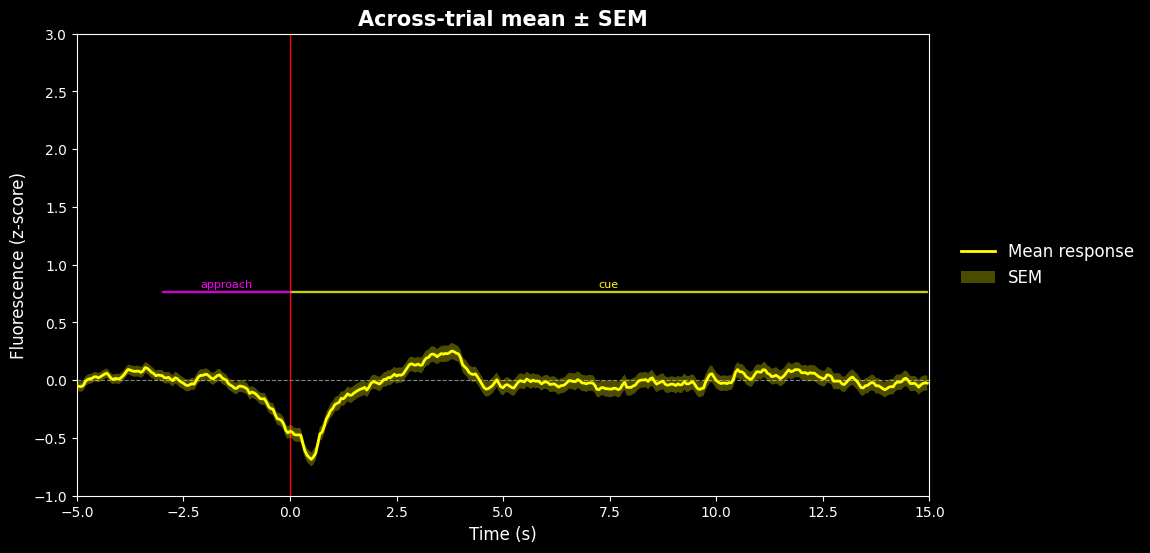

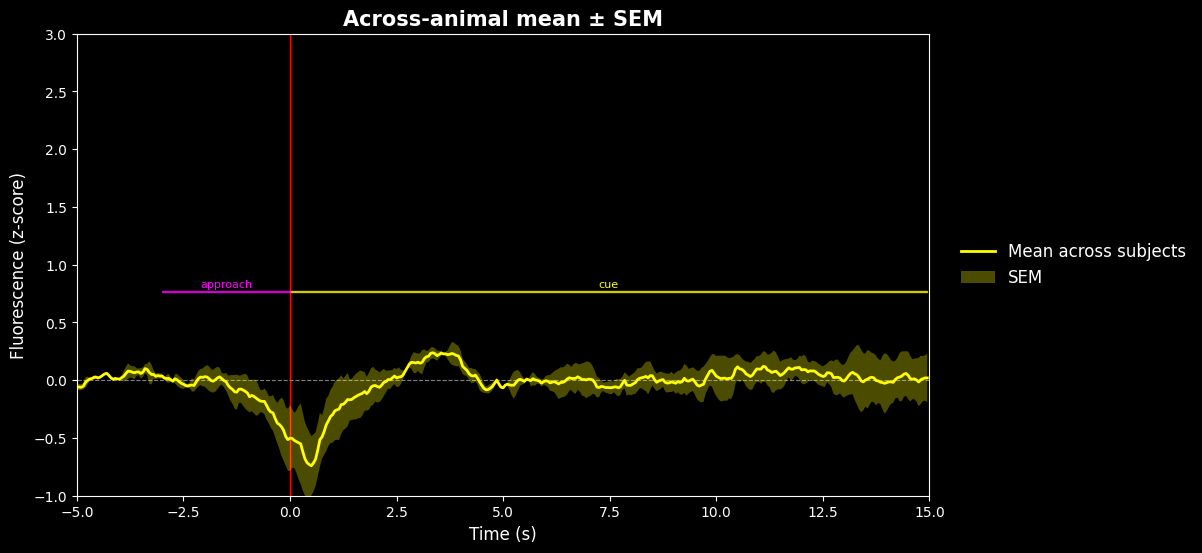

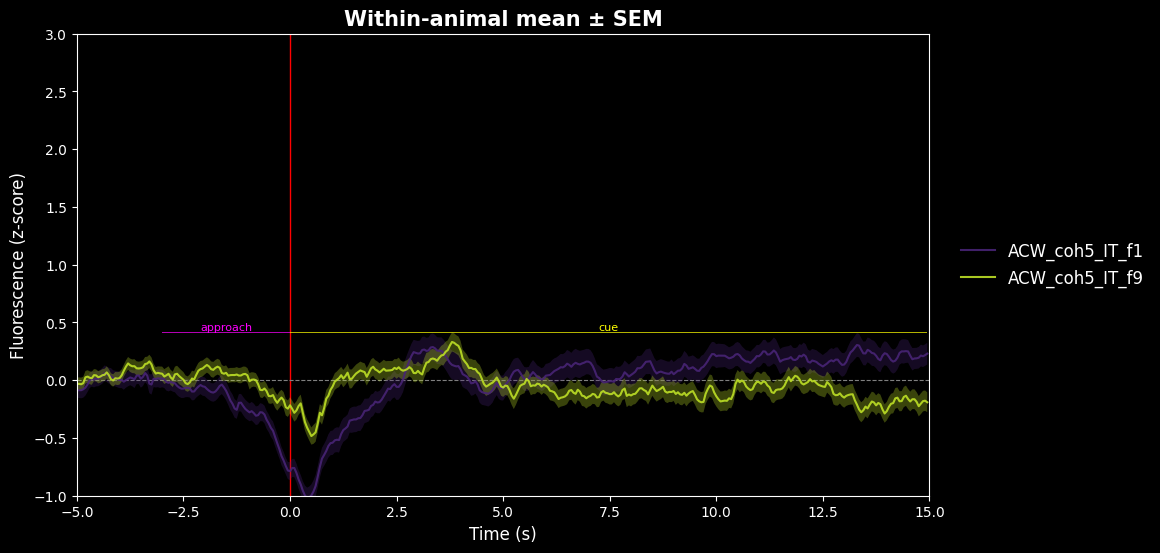

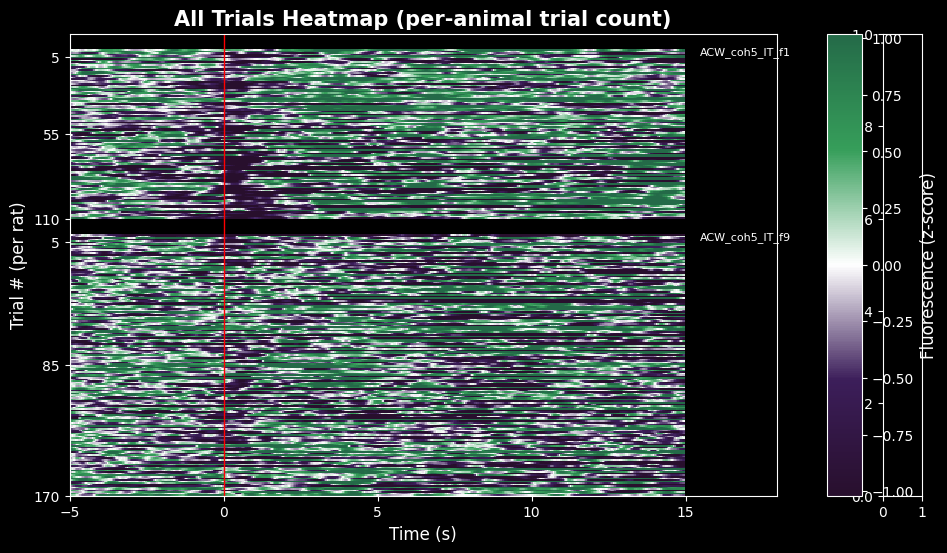

🖼️  Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_all_trials_heatmap.png
🖼️  Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_all_trials_heatmap.pdf
🖼️  Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_all_trials_heatmap.svg


c:\Python\Whitebirch_et_al._2026\fp_func_acw.py:8277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_heatmap_within_rat.tight_layout()


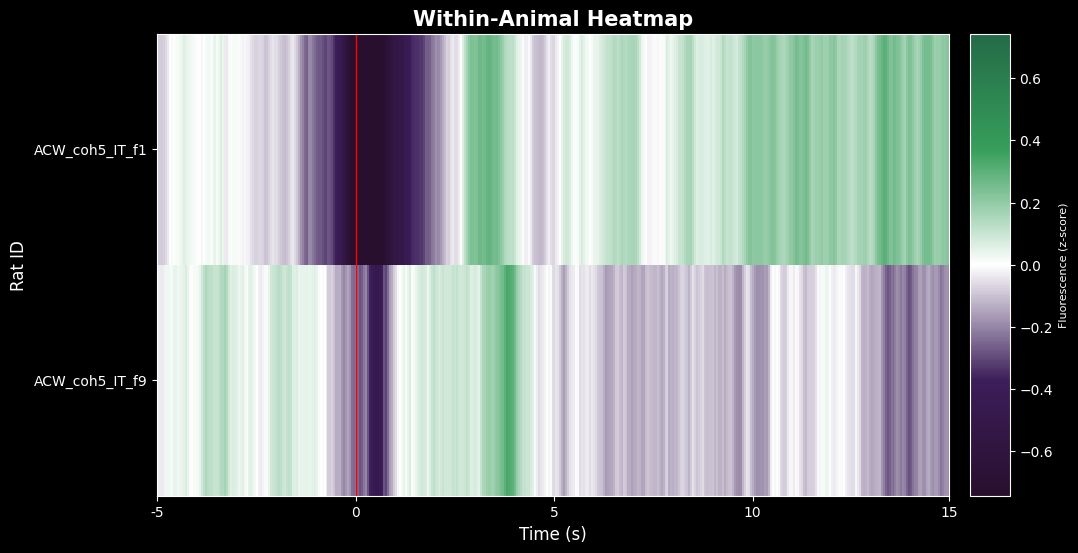

🖼️  Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_within_rat_heatmap.png
🖼️  Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_within_rat_heatmap.pdf
🖼️  Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_within_rat_heatmap.svg


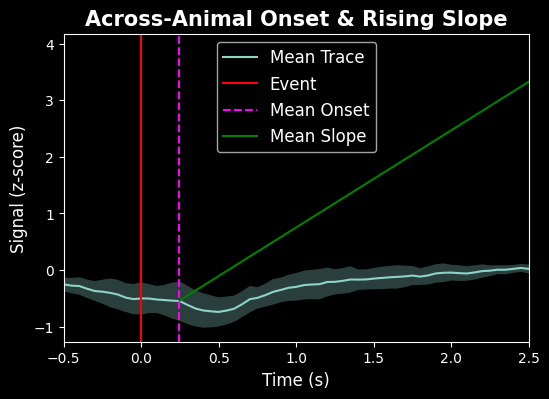

💾 Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_across_rat_epocs_bslnd.feather
💾 Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_across_rat_epocs_bslnd.csv
💾 Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_across_rat_stats.feather
💾 Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_across_rat_stats.csv
💾 Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_across_rat_PER_ANIMAL_summary_stats.feather
💾 Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_across_rat_PER_ANIMAL_summary_stats.csv
💾 Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_across_rat_summary.feather
💾 Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_across_rat_summary.csv
💾 Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_across_rat_summary.txt
🖼️  Saved: processed_CR__GCaMP8s_high_risk_f1_f9_GCaMP_missed_infusion_across_rat.png
🖼️  Saved: processed_CR__GCaMP8s

## 🐀 Within-Rat Data

### Per-Rat Epoc Stats

,epoc_id,response_latency_sec,rising_slope,time_to_peak_sec,onset_peak_amplitude,overall_peak_amp,overall_peak_amp_timestamp,cue_mean,approach_mean,auc_pre,auc_post,source_file,rat_id
0,ACW_coh5_IT_f1_onset_14.550s,0.00,2.682479,3.00,1.185243,1.649013,3.85,0.833798,0.258525,0.771193,12.463683,ACW_coh5a_111325_0001_ACW_coh5_IT_f1_GCaMP_mis...,ACW_coh5_IT_f1
1,ACW_coh5_IT_f1_onset_21.600s,0.50,1.091316,2.50,2.459574,2.535871,3.00,0.618053,0.577674,1.711309,9.235716,ACW_coh5a_111325_0001_ACW_coh5_IT_f1_GCaMP_mis...,ACW_coh5_IT_f1
2,ACW_coh5_IT_f1_onset_26.300s,0.30,6.467392,1.20,0.184249,2.074911,7.75,-0.159230,0.550571,1.651078,-2.361527,ACW_coh5a_111325_0001_ACW_coh5_IT_f1_GCaMP_mis...,ACW_coh5_IT_f1
3,ACW_coh5_IT_f1_onset_38.850s,0.40,0.813451,2.60,0.500310,0.567457,2.55,-0.782557,0.127263,0.430532,-11.663022,ACW_coh5a_111325_0001_ACW_coh5_IT_f1_GCaMP_mis...,ACW_coh5_IT_f1
4,ACW_coh5_IT_f1_onset_51.950s,0.00,NaN,NaN,0.105806,3.030058,5.40,0.641151,-0.278828,-0.813498,9.571171,ACW_coh5a_111325_0001_ACW_coh5_IT_f1_GCaMP_mis...,ACW_coh5_IT_f1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,ACW_coh5_IT_f9_onset_3317.750s,0.00,0.424458,3.00,1.010431,1.875300,3.85,0.228678,0.590697,1.758540,3.411706,ACW_coh5d_112325_0002_ACW_coh5_IT_f9_GCaMP_mis...,ACW_coh5_IT_f9
276,ACW_coh5_IT_f9_onset_3337.400s,0.15,2.831252,2.40,0.080701,1.640977,5.60,-0.223937,-0.387087,-1.134470,-3.283954,ACW_coh5d_112325_0002_ACW_coh5_IT_f9_GCaMP_mis...,ACW_coh5_IT_f9
277,ACW_coh5_IT_f9_onset_3345.150s,0.00,0.616585,2.60,1.997808,2.282392,2.60,0.113586,0.475991,1.430377,1.675566,ACW_coh5d_112325_0002_ACW_coh5_IT_f9_GCaMP_mis...,ACW_coh5_IT_f9
278,ACW_coh5_IT_f9_onset_3373.050s,0.00,-0.940440,2.05,1.517832,2.191269,1.90,0.593223,0.304918,0.893052,8.841140,ACW_coh5d_112325_0002_ACW_coh5_IT_f9_GCaMP_mis...,ACW_coh5_IT_f9


### Within-Animal Averaged Epocs (Mean)

...

### Figure: trial

### Figure: across

### Figure: within

## 🔹 Across-Trial vs Across-Animal Summary Metrics (Exact Saved Values)

,Metric,Across-Trial,Across-Animal
0,cue_mean,-0.029868,-0.020232
1,cue_sem,0.043271,0.044968
2,approach_mean,-0.079869,-0.101980
3,approach_sem,0.037837,0.103186
4,auc_pre_mean,-0.229191,-0.293979
5,auc_pre_sem,0.111946,0.302343
6,auc_post_mean,-0.436367,-0.291427
7,auc_post_sem,0.647510,0.676386


In [3]:
########################################################################################################################
# updated 01.22.26 to handle multiple animals in coh5 analysis
# new streamlined function to parallel peak processing
import os
import glob
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from fp_func_acw import run_perievent_pipeline, chunks_concat_compute_plot


# -----------------------------
# INPUT CONFIGURATION
# -----------------------------

feather_folder = [
     #r"D:\ACW\photometry\cohort_5_101325\extracted\training\processed_training_early_GCaMP6s_lowrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\training\processed_training_early_GCaMP6s_highrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\training\processed_training_late_GCaMP6s_lowrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\training\processed_training_late_GCaMP6s_highrisk", 
    
     #r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_IntA_SA_early_GCaMP6s_lowrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_IntA_SA_early_GCaMP6s_highrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_IntA_SA_mid_GCaMP6s_highrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_IntA_SA_mid_GCaMP6s_lowrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_IntA_SA_late_GCaMP6s_lowrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_IntA_SA_late_GCaMP6s_highrisk",

     #r"D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP6s_highrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP8s_lowrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP8s_highrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\noncont\processed_noncont_early_GCaMP6s_lowrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\noncont\processed_noncont_early_GCaMP6s_highrisk", 
     #r"D:\ACW\photometry\cohort_5_101325\extracted\noncont\processed_noncont_mid_GCaMP6s_lowrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\noncont\processed_noncont_mid_GCaMP6s_highrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\noncont\processed_noncont_late_GCaMP6s_lowrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\noncont\processed_noncont_late_GCaMP6s_highrisk",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\extinction\processed_extinction_GCaMP6s_early",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\extinction\processed_extinction_GCaMP6s_mid",
     #r"D:\ACW\photometry\cohort_5_101325\extracted\extinction\processed_extinction_GCaMP6s_late",
     r"D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_CR_GCaMP8s_highrisk"

]

# this should create a new folder in the same location as the feather_folder above
# the feather_folder is named like e.g. "processed_[phase]_[GCaMP]_[risk], and contains the results of the pre-processing for each individual animal

save_base = r"D:\ACW\photometry\cohort_5_101325\extracted\CR\processed_missed_infusion_CR_GCaMP8s_high-risk_0_15_window"

# the excel file path is used to plot results from the FiPhoPHA bootstrapped confidence interval analysis from Drakopoulos et al., 2025
#excel_file_path = r"D:\ACW\photometry\cohort_5_101325\analysis\for_bootstrap\results_bCI_95_1000ms_threshold\processed_welltrainedSA_vs_CR_GCaMP6s_high_low_risk_f2_f5_m3_m4_m5_m8_m9_GCaMP_missed_infusion_type2_within_rat_epoc_bslnd_means_forBootstrap_results.xlsx"
excel_file_path = None


# this is a condition that determines appearance and saving of figures
paperfigs = False
paperfig_path = r"D:\ACW\photometry\cohort_5_101325\analysis\figures"
#paperfig_path = None




file_pattern = [
    
    '*ACW_coh5_IT_*_GCaMP_missed_infusion_epocs.feather', 

    #'*ACW_coh5_IT_f2_GCaMP_missed_infusion_epocs.feather', 
    #'*ACW_coh5_IT_m3_GCaMP_missed_infusion_epocs.feather',  
    #'*ACW_coh5_IT_f5_GCaMP_missed_infusion_epocs.feather', 
    #'*ACW_coh5_IT_m4_GCaMP_missed_infusion_epocs.feather', 
    #'*ACW_coh5_IT_m5_GCaMP_missed_infusion_epocs.feather',  
    #'*ACW_coh5_IT_m8_GCaMP_missed_infusion_epocs.feather', 
    #'*ACW_coh5_IT_m9_GCaMP_missed_infusion_epocs.feather', 

    #'*ACW_coh5_IT_f2_GCaMP_drug_infusion_epocs.feather', 
    #'*ACW_coh5_IT_m3_GCaMP_drug_infusion_epocs.feather',  
    #'*ACW_coh5_IT_f5_GCaMP_drug_infusion_epocs.feather', 
    #'*ACW_coh5_IT_m4_GCaMP_drug_infusion_epocs.feather', 
    #'*ACW_coh5_IT_m5_GCaMP_drug_infusion_epocs.feather',  
    #'*ACW_coh5_IT_m8_GCaMP_drug_infusion_epocs.feather', 
    #'*ACW_coh5_IT_m9_GCaMP_drug_infusion_epocs.feather', 


    # for program start
    
    #late training
    #'*101825*ACW_coh5_IT_f2_GCaMP_program_start_epocs.feather',  
    #'*101925*ACW_coh5_IT_f5_GCaMP_program_start_epocs.feather',
    #'*101825*ACW_coh5_IT_m3_GCaMP_program_start_epocs.feather',
    #'*101925*ACW_coh5_IT_m4_GCaMP_program_start_epocs.feather',

    #early inta sa
    #'*102225*ACW_coh5_IT_f5_GCaMP_drug_available_epocs.feather',
    #'*102225*ACW_coh5_IT_m5_GCaMP_drug_available_epocs.feather',
    
    #mid
    #'*102525*ACW_coh5_IT_f2_GCaMP_drug_available_epocs.feather',
    #'*102625*ACW_coh5_IT_m3_GCaMP_drug_available_epocs.feather',  
    #'*102725*ACW_coh5_IT_f5_GCaMP_drug_available_epocs.feather',  
    #'*102725*ACW_coh5_IT_m5_GCaMP_drug_available_epocs.feather', 
    
    #late
    #'*102925*ACW_coh5_IT_f2_GCaMP_drug_available_epocs.feather',
    #'*103025*ACW_coh5_IT_m3_GCaMP_drug_available_epocs.feather',  
    #'*110325*ACW_coh5_IT_m4_GCaMP_drug_available_epocs.feather',  
    #'*110325*ACW_coh5_IT_f5_GCaMP_drug_available_epocs.feather', 
    #'*110425*ACW_coh5_IT_m5_GCaMP_drug_available_epocs.feather',
    #'*110525*ACW_coh5_IT_m8_GCaMP_drug_available_epocs.feather',
    #'*110625*ACW_coh5_IT_m8_GCaMP_drug_available_epocs.feather',
    #'*110625*ACW_coh5_IT_m9_GCaMP_drug_available_epocs.feather',


    #'*ACW_coh5_IT_f2_GCaMP_active_lever_epocs.feather',    
    #'*ACW_coh5_IT_f5_GCaMP_active_lever_epocs.feather',    
    #'*ACW_coh5_IT_m3_GCaMP_active_lever_epocs.feather',    
    #'*ACW_coh5_IT_m4_GCaMP_active_lever_epocs.feather',    
    #'*ACW_coh5_IT_m8_GCaMP_active_lever_epocs.feather',    
    #'*ACW_coh5_IT_m5_GCaMP_active_lever_epocs.feather',    
    #'*ACW_coh5_IT_m9_GCaMP_active_lever_epocs.feather', 
    #'*ACW_coh5_IT_*_GCaMP_drug_available_epocs.feather', 

    #'*ACW_coh5_IT_f3_GCaMP_missed_infusion_epocs.feather',    
    #'*ACW_coh5_IT_f4_GCaMP_missed_infusion_epocs.feather',    
    #'*ACW_coh5_IT_f10_GCaMP_missed_infusion_epocs.feather', 
    
    #'*111325*ACW_coh5_IT_f2_GCaMP_program_start_epocs.feather',  
    #'*111525*ACW_coh5_IT_m3_GCaMP_program_start_epocs.feather',  
    #'*111425*ACW_coh5_IT_m4_GCaMP_program_start_epocs.feather',  
    #'*111525*ACW_coh5_IT_f5_GCaMP_program_start_epocs.feather',  
    #'*111525*ACW_coh5_IT_m5_GCaMP_program_start_epocs.feather',  
    #'*111725*ACW_coh5_IT_m8_GCaMP_program_start_epocs.feather',  
    #'*111725*ACW_coh5_IT_m9_GCaMP_program_start_epocs.feather',  
    
    #'*112025*ACW_coh5_IT_f2_GCaMP_missed_infusion_epocs.feather',  
    #'*112225*ACW_coh5_IT_m3_GCaMP_missed_infusion_epocs.feather',  
    #'*112125*ACW_coh5_IT_m4_GCaMP_missed_infusion_epocs.feather',  
    #'*112225*ACW_coh5_IT_f5_GCaMP_missed_infusion_epocs.feather',  
    #'*112225*ACW_coh5_IT_m5_GCaMP_missed_infusion_epocs.feather',  
    #'*112425*ACW_coh5_IT_m8_GCaMP_missed_infusion_epocs.feather',  
    #'*112425*ACW_coh5_IT_m9_GCaMP_missed_infusion_epocs.feather',  
    





]


# Normalize inputs, always lists for these variables
if isinstance(feather_folder, str):
    feather_folder = [feather_folder]

if isinstance(file_pattern, str):
    file_pattern = [file_pattern]

multiday = len(feather_folder) > 1


# -----------------------------
# DETECT MULTIDAY
# -----------------------------

    
matched_files = []

for folder in feather_folder:
    for pattern in file_pattern:
        matched_files.extend(glob.glob(os.path.join(folder, pattern)))
        


# ------------------------------------------------------------
# BUILD COMBINED processed_phase FROM ALL INPUT FOLDERS
# ------------------------------------------------------------

paradigms = set()
phases = set()
fluors = set()
risks = set()

for folder in feather_folder:
    folder_name = os.path.basename(folder)

    # Remove leading "processed_"
    if folder_name.startswith("processed_"):
        folder_name = folder_name[len("processed_"):]

    parts = folder_name.split("_")

    # Detect fluor (anything starting with GCaMP)
    for p in parts:
        if p.startswith("GCaMP"):
            fluors.add(p)

    # Detect risk
    if "lowrisk" in parts:
        risks.add("low")
    if "highrisk" in parts:
        risks.add("high")
    if "low-high-risk" in folder_name.lower():
        risks.update(["low", "high"])
    if "low_high_risk" in folder_name.lower():
        risks.update(["low", "high"])

    # Detect phase
    for phase in ["early", "mid", "late"]:
        if phase in parts:
            phases.add(phase)

    # Everything before fluor is paradigm + possibly phase
    # So capture paradigm by removing phase + fluor + risk tokens
    ignore_tokens = {"early", "mid", "late", "lowrisk", "highrisk"}
    paradigm_tokens = [
        p for p in parts
        if p not in ignore_tokens
        and not p.startswith("GCaMP")
        and "risk" not in p
    ]

    if paradigm_tokens:
        paradigms.add("_".join(paradigm_tokens))

# Sort for consistency
paradigms = sorted(paradigms)
phases = sorted(phases)
fluors = sorted(fluors)
risks = sorted(risks)

# Collapse
paradigm_str = "_".join(paradigms)
phase_str = "_".join(phases)
fluor_str = "_".join(fluors)
risk_str = "_".join(risks)

if risk_str:
    risk_str = f"{risk_str}_risk"

# Final processed_phase
processed_phase = f"processed_{paradigm_str}_{phase_str}_{fluor_str}_{risk_str}"

print(f"Combined processed_phase: {processed_phase}")



    
matched_files = sorted(list(set(matched_files)))
#print(matched_files)
if len(matched_files) == 0:
    raise ValueError("No matched feather files found. Check folder paths and file_pattern.")

    
# -----------------------------
# FILENAME PARSING
# -----------------------------
def parse_rat_event(filename):
    fname = Path(filename).stem
    rat_match = re.search(r'ACW_coh5_IT_[fm]\d+', fname)
    rat = rat_match.group(0) if rat_match else 'unknown_rat'
    if rat_match:
        start_idx = rat_match.end() + 1
        end_idx = fname.rfind('_epocs')
        eventname = fname[start_idx:end_idx]
    else:
        eventname = 'unknown_event'
    eventname = eventname.strip('_')
    eventname = re.sub(r'_combined$', '', eventname)
    return rat, eventname


# -----------------------------
# Helper: extract date from filename
# -----------------------------
def parse_date_from_filename(filename):
    fname = Path(filename).stem
    # Look for the first 6-digit number after 'ACW_coh5[cd]_'
    match = re.search(r'ACW_coh5[abcde]_(\d{6})', fname)
    if match:
        return match.group(1)
    else:
        return "unknown_date"

    
'''
# ---------------------------------------------------------------------------------------------------------------------------------------------------

# Keep first file per rat per day - this is for e.g. separating program start from other drug_available during IntA SA
# -----------------------------
from collections import OrderedDict

first_file_per_rat_day = OrderedDict()

for f in matched_files:
    rat, _ = parse_rat_event(f)
    date_str = parse_date_from_filename(f)
    key = (rat, date_str)
    if key not in first_file_per_rat_day:
        first_file_per_rat_day[key] = f

matched_files = list(first_file_per_rat_day.values())


print("📂 Using first file per rat per day:")
for f in matched_files:
    print("   ", Path(f).name)
    
# ---------------------------------------------------------------------------------------------------------------------------------------------------
'''


    
    
# -----------------------------
# TIME AND WINDOW PARAMETERS
# -----------------------------
subset = None   # a subset of events, if don't want to include all. e.g. 5 for first 5, -5 for last 5, or [4,8] for 4th through 8th 
compute_kwargs = {
    "baseline_trange": (-10, -3), #(-0.50, 0) for noncontingent events, (-10,-3) for lever presses and such
    "approach_window": (-3, 0),
    "cue_window": (0,15),   # 8 seconds for the noncontigent houselight, avail unavail transitions, program start... 4 seconds for cue light/infusion, lever presses
    "auc_pre_window": (-3, 0),
    "auc_post_window": (0,15),
    "new_fs": 20.0,
    "trange": [-10, 25],
    "analysis_trange": None
}

compute_kwargs["ts"] = np.arange(
    compute_kwargs["trange"][0],
    compute_kwargs["trange"][0] + compute_kwargs["trange"][1],
    1 / compute_kwargs["new_fs"]
)



# Generate eventname and rat_str
all_events = sorted({parse_rat_event(f)[1] for f in matched_files})
eventname = "-".join(all_events)
eventname = re.sub(r'[<>:"/\\|?*]', '_', eventname)
print(f'event name: {eventname}')


all_rats = sorted({parse_rat_event(f)[0] for f in matched_files})
rat_str = "-".join(all_rats)
rat_str = re.sub(r'[<>:"/\\|?*]', '_', rat_str)


save_dir = os.path.join(save_base, f"{eventname}_processed")
os.makedirs(save_dir, exist_ok=True)


print(f"📁 Saving pipeline outputs to:\n{save_dir}")

# -----------------------------
# RUN PIPELINE
# -----------------------------
pipeline_results = run_perievent_pipeline(
    matched_files,
    save_dir=save_dir,
    processed_phase=processed_phase,
    eventname=eventname,
    subset=subset,
    compute_kwargs=compute_kwargs,
    overwrite=False,
    save_within_rat=True,
    master_xlim=(-5,15),
    master_ylim=(-1,3),
    excel_file_path = excel_file_path,
    plot_group_comparison=True,
    plot_baseline_significance=True,
    paperfigs=paperfigs, 
    paperfig_path=paperfig_path,  
    master_figsize=  (2, 2),  #(2,2),  smaller for cue, noncont etc fig.
    plot_onset_detection=False,  
)





from IPython.display import display, Markdown

# --- Convenience references ---
per_rat = pipeline_results["per_rat"]
per_rat_stats = pipeline_results["per_rat_stats"]
per_epoc_stats_within = pipeline_results["per_epoc_stats_within_rat"]

per_file_epocs = pipeline_results["file_level_epoc_latency_count"]

within_animal_epocs_mean = pipeline_results["within_animal_epocs_mean"]
within_animal_epocs_sem = pipeline_results["within_animal_epocs_sem"]

combined_epocs_trial = pipeline_results["combined_epocs_across_trial"]
combined_stats_trial = pipeline_results["combined_stats_across_trial"]
combined_events_trial = pipeline_results["combined_events_info_across_trial"]

across_animal_stats = pipeline_results["across_animal_stats"]
across_animal_epocs = pipeline_results["across_animal_epocs"]
per_animal_stats = pipeline_results["per_animal_stats"]
combined_events_animal = pipeline_results["combined_events_info_across_animal"]

fig_all = pipeline_results["fig_all"]

def display_perievent_summary():
    # --- Within-Rat Data ---
    display(Markdown("## 🐀 Within-Rat Data"))

    display(Markdown("### Per-Rat Epoc Stats"))
    display(per_epoc_stats_within)

    # --- Within-Animal Averaged Epocs (Mean) ---
    display(Markdown("### Within-Animal Averaged Epocs (Mean)"))
    mean_df = within_animal_epocs_mean.copy()
    # Ensure columns are rat IDs with 'time' first
    cols_order = ["time"] + [c for c in mean_df.columns if c != "time"]
    mean_df = mean_df[cols_order]
    display(mean_df)
    

    # --- Within-Animal Averaged Epocs (SEM) ---
    display(Markdown("### Within-Animal Averaged Epocs (SEM)"))
    sem_df = within_animal_epocs_sem.copy()
    # Ensure columns are rat IDs with 'time' first
    cols_order = ["time"] + [c for c in sem_df.columns if c != "time"]
    sem_df = sem_df[cols_order]
    display(sem_df)

    # --- Per-Rat Summary Stats ---
    display(Markdown("### Per-Rat Summary Stats"))
    for rat, stats in per_rat_stats.items():
        display(Markdown(f"**Rat {rat}:**"))
        display(pd.DataFrame([{
            "cue_mean": stats["cue_stats"][0],
            "cue_sem": stats["cue_stats"][1],
            "approach_mean": stats["approach_stats"][0],
            "approach_sem": stats["approach_stats"][1],
            "auc_pre_mean": stats["auc_pre_stats"][0],
            "auc_pre_sem": stats["auc_pre_stats"][1],
            "auc_post_mean": stats["auc_post_stats"][0],
            "auc_post_sem": stats["auc_post_stats"][1]
        }]))

    # --- Per-file events ---
    display(Markdown("## 📊 Across-file event onsets, count"))
    display(per_file_epocs)
    
    # --- Across-Trial Data ---
    display(Markdown("## 📊 Across-Trial Data"))
    display(Markdown("### Combined Epocs"))
    display(combined_epocs_trial)
    display(Markdown("### Combined Stats"))
    display(combined_stats_trial)
    display(Markdown("### Combined Events Info"))
    display(combined_events_trial)

    # --- Across-Animal Data ---
    display(Markdown("## 🐁 Across-Animal Data"))
    display(Markdown("### Time-Resolved Stats"))
    display(across_animal_stats)
    display(Markdown("### Mean Trace Across Animals"))
    display(across_animal_epocs)
    display(Markdown("### Per-Animal Summary Stats"))
    display(per_animal_stats)
    display(Markdown("### Combined Events Info"))
    display(combined_events_animal)

    # --- Figures ---
    display(Markdown("## 🖼️ Figures"))
    for key, fig in fig_all.items():
        if fig is not None:
            display(Markdown(f"### Figure: {key}"))
            #display(fig)  # Uncomment to show figures


# --- Call display function ---
display_perievent_summary()

import pandas as pd
from IPython.display import display, Markdown

# --- Extract exact across-animal summary metrics ---
across_animal_stats = pipeline_results["across_animal_stats"]  # this is the DataFrame per_animal_stats_df

# Compute the mean across animals for each metric
across_animal_summary = across_animal_stats.mean(axis=0)

# Build comparison table using exact saved values
comparison_data = {
    "Metric": [
        "cue_mean", "cue_sem",
        "approach_mean", "approach_sem",
        "auc_pre_mean", "auc_pre_sem",
        "auc_post_mean", "auc_post_sem"
    ],

    "Across-Trial": [
        pipeline_results["cue_stats_across_trial"][0],
        pipeline_results["cue_stats_across_trial"][1],
        pipeline_results["approach_stats_across_trial"][0],
        pipeline_results["approach_stats_across_trial"][1],
        pipeline_results["auc_pre_stats_across_trial"][0],
        pipeline_results["auc_pre_stats_across_trial"][1],
        pipeline_results["auc_post_stats_across_trial"][0],
        pipeline_results["auc_post_stats_across_trial"][1],
    ],

    "Across-Animal": [
        pipeline_results["cue_stats_across_animal"][0],
        pipeline_results["cue_stats_across_animal"][1],
        pipeline_results["approach_stats_across_animal"][0],
        pipeline_results["approach_stats_across_animal"][1],
        pipeline_results["auc_pre_stats_across_animal"][0],
        pipeline_results["auc_pre_stats_across_animal"][1],
        pipeline_results["auc_post_stats_across_animal"][0],
        pipeline_results["auc_post_stats_across_animal"][1],
    ]
}

comparison_df = pd.DataFrame(comparison_data)
# --- Display ---
display(Markdown("## 🔹 Across-Trial vs Across-Animal Summary Metrics (Exact Saved Values)"))
display(comparison_df)
 
    
    
    

In [ ]:

# updated 01.22.26 to handle multiple rats
from fp_func_acw_051926 import load_combine_and_save_peak_data_multi, peaks_process_multi_folders_patterns
from pathlib import Path
import re
import pandas as pd


folders = [
    r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_IntA_SA_mid_GCaMP6s_highrisk",
    r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_IntA_SA_late_GCaMP6s_highrisk",
    #r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_IntA_SA_mid_GCaMP6s_lowrisk",
    #r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_IntA_SA_late_GCaMP6s_lowrisk"


]

save_base = r"D:\ACW\photometry\cohort_5_101325\extracted\IntA_SA\processed_unavail_late_peaks_IntA_SA_mid-late_GCaMP6s_high-risk"
'''
file_patterns = [
    "*_Avail_*ACW_coh5_IT*",
]
'''

file_patterns = [
    #"*_Avail_*ACW_coh5_IT_f2*",
    #"*_Avail_*ACW_coh5_IT_f5*",
    #"*_Avail_*ACW_coh5_IT_m3*",
    #"*_Avail_*ACW_coh5_IT_m4*",
    #"*_Avail_*ACW_coh5_IT_m8*",
    #"*_Avail_*ACW_coh5_IT_m5*",
    #"*_Avail_*ACW_coh5_IT_m9*",
    "*_Unavail_late_*ACW_coh5_IT*"
]

preproc_info_txt_pattern = "*_Unavail_late_*ACW_coh5_IT*_preproc_info.txt"

rebaseline_window = None

per_rat_df, summary_all_df, combined_outputs_all = peaks_process_multi_folders_patterns(
    folders,
    file_patterns,
    preproc_info_txt_pattern,
    filename_prefix_base="combined_",
    target_rat=None,
    rebaseline_window = rebaseline_window,
    save_base = save_base
)

display(per_rat_df)        # Each rat has its own column
display(summary_all_df)    # Across-animal mean ± SEM

